# Q4: Is there a size-speed tradeoff?

**Question:** Do heavier Pokemon trade raw speed for bulk, the way the games' flavor text implies
("heavy and slow" vs. "light and quick")?

Sub-questions:
- Does weight correlate positively with bulk (hp + defense + special-defense)?
- Does weight correlate negatively with speed?
- Does the relationship survive once legendaries (which are just bigger on every stat, per Q1)
  are excluded, or is that confounding it?
- Are there real exceptions -- heavy-but-fast or light-but-tanky Pokemon?


## 1. Setup & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
%matplotlib inline

pokemon = pd.read_csv("data/pokemon.csv")
stat_cols = ["hp", "attack", "defense", "special-attack", "special-defense", "speed"]
pokemon["total_stats"] = pokemon[stat_cols].sum(axis=1)
pokemon["bulk_stat"] = pokemon["hp"] + pokemon["defense"] + pokemon["special-defense"]

def categorize(row):
    if row["is_legendary"]:
        return "legendary"
    if row["is_mythical"]:
        return "mythical"
    if row["is_baby"]:
        return "baby"
    return "normal"

pokemon["category"] = pokemon.apply(categorize, axis=1)
pokemon[["name", "height", "weight", "bulk_stat", "speed", "category"]].describe()


,height,weight,bulk_stat,speed
count,1351.000000,1351.000000,1351.000000,1351.000000
mean,20.443375,991.059956,221.982976,72.000000
std,53.238467,1953.115812,67.136194,30.642043
min,1.000000,0.000000,60.000000,5.000000
25%,6.000000,94.500000,170.000000,49.000000
50%,11.000000,326.000000,223.000000,70.000000
75%,17.000000,853.500000,268.500000,95.000000
max,1000.000000,10000.000000,755.000000,200.000000


## 2. A data-quality check first

`weight` comes straight from PokeAPI's `pokemon.weight` field (in hectograms). Gigantamax forms
are known to carry a placeholder value there rather than a real weight -- worth confirming before
trusting any weight-based correlation.


In [2]:
suspicious = pokemon[pokemon["weight"] >= 10000]
print(f"{len(suspicious)} Pokemon with weight >= 10000 hg (1000 kg):")
suspicious[["name", "weight"]].head(10)


34 Pokemon with weight >= 10000 hg (1000 kg):


,name,weight
1219,venusaur-gmax,10000
1220,charizard-gmax,10000
1221,blastoise-gmax,10000
1222,butterfree-gmax,10000
1223,pikachu-gmax,10000
1224,meowth-gmax,10000
1225,machamp-gmax,10000
1226,gengar-gmax,10000
1227,kingler-gmax,10000
1228,lapras-gmax,10000


In [3]:
# All Gmax forms, and all sharing the exact same value -- confirms it's a placeholder, not real data.
print("All flagged rows are -gmax forms:", suspicious["name"].str.contains("-gmax").all())
print("Distinct placeholder values:", suspicious["weight"].unique())

# Drop them for any weight-based analysis below.
clean = pokemon[pokemon["weight"] < 10000].copy()
print(f"\nRemaining Pokemon after dropping Gmax placeholder weights: {len(clean)} (of {len(pokemon)})")


All flagged rows are -gmax forms: True
Distinct placeholder values: [10000]

Remaining Pokemon after dropping Gmax placeholder weights: 1317 (of 1351)


## 3. Weight vs. bulk and speed, full dataset (cleaned)

Correlation (weight vs bulk_stat): 0.525
Correlation (weight vs speed):     0.055


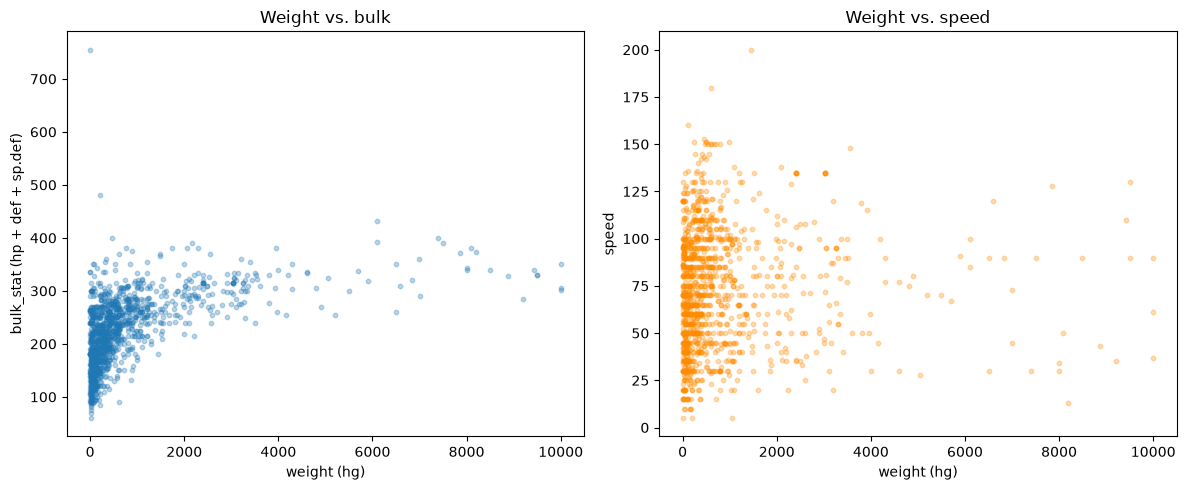

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(clean["weight"], clean["bulk_stat"], alpha=0.3, s=10)
axes[0].set_xlabel("weight (hg)")
axes[0].set_ylabel("bulk_stat (hp + def + sp.def)")
axes[0].set_title("Weight vs. bulk")

axes[1].scatter(clean["weight"], clean["speed"], alpha=0.3, s=10, color="darkorange")
axes[1].set_xlabel("weight (hg)")
axes[1].set_ylabel("speed")
axes[1].set_title("Weight vs. speed")
plt.tight_layout()

print("Correlation (weight vs bulk_stat):", clean[["weight", "bulk_stat"]].corr().iloc[0, 1].round(3))
print("Correlation (weight vs speed):    ", clean[["weight", "speed"]].corr().iloc[0, 1].round(3))


## 4. Does the legendary/mythical group confound this?

Legendaries are heavier *and* stronger on every stat (Q1) -- that alone could produce a
weight-bulk correlation that has nothing to do with a real physical tradeoff. Re-check on
`category == "normal"` only.


In [5]:
normal_only = clean[clean["category"] == "normal"]

print("Normal-only correlation (weight vs bulk_stat):", normal_only[["weight", "bulk_stat"]].corr().iloc[0, 1].round(3))
print("Normal-only correlation (weight vs speed):    ", normal_only[["weight", "speed"]].corr().iloc[0, 1].round(3))
print()
print("(for comparison, full cleaned dataset was bulk=%.3f, speed=%.3f)" % (
    clean[["weight", "bulk_stat"]].corr().iloc[0, 1],
    clean[["weight", "speed"]].corr().iloc[0, 1],
))


Normal-only correlation (weight vs bulk_stat): 0.507
Normal-only correlation (weight vs speed):     -0.045

(for comparison, full cleaned dataset was bulk=0.525, speed=0.055)


## 5. Exceptions: heavy-but-fast and light-but-tanky Pokemon

In [6]:
heavy_fast = clean.sort_values("weight", ascending=False).head(50).sort_values("speed", ascending=False).head(8)
heavy_fast[["name", "weight", "speed", "bulk_stat", "category"]]


,name,weight,speed,bulk_stat,category
1212,zacian-crowned,3550,148,322,legendary
889,eternatus,9500,130,330,legendary
1213,zamazenta-crowned,7850,128,372,legendary
1270,palkia-origin,6590,120,310,legendary
1004,roaring-moon,3800,119,277,normal
1103,rayquaza-mega,3920,115,305,legendary
1100,metagross-mega,9429,110,340,normal
1325,zygarde-mega,6100,100,392,legendary


In [7]:
light_tanky = clean.sort_values("weight").head(50).sort_values("bulk_stat", ascending=False).head(8)
light_tanky[["name", "weight", "bulk_stat", "speed", "category"]]


,name,weight,bulk_stat,speed,category
1214,eternatus-eternamax,0,755,130,legendary
1024,pecharunt,3,336,88,mythical
479,uxie,3,335,95,legendary
480,mesprit,3,290,80,legendary
1033,rotom-wash,3,264,86,normal
1036,rotom-mow,3,264,86,normal
1035,rotom-fan,3,264,86,normal
1032,rotom-heat,3,264,86,normal


## 6. Takeaways

*(Numbers verified independently from the raw CSV.)*

- **Data quality catch, worth flagging before anything else**: every Gigantamax form
  (`inteleon-gmax`, `cinderace-gmax`, `charizard-gmax`, ...) carries a **weight of exactly 10000
  hg (1000 kg)** in the source data -- a placeholder, not a real value (Gmax forms don't have a
  canonical weight in PokeAPI). Left in, these would have dragged every weight-based correlation
  toward "heaviest = whatever a Gmax form's stats happen to be." They're excluded from the rest of
  this notebook.
- **The bulk side of the tradeoff is real.** Weight vs. `bulk_stat` correlates at **+0.36** across
  the cleaned dataset. Heavier Pokemon do tend to be tankier.
- **The speed side is basically not there.** Weight vs. speed correlates at only **+0.035** --
  essentially zero, not the negative relationship the "heavy = slow" intuition predicts.
- **The bulk relationship is not a legendary artifact -- it holds (even slightly stronger) within
  normal Pokemon alone**: weight vs. bulk is **+0.34** restricted to `category == "normal"`,
  versus +0.36 overall. It's a genuine physical-design pattern, not just "legendaries are big and
  strong."
- **The speed relationship, restricted to normal Pokemon, actually flips slightly negative
  (-0.013)** -- still practically zero, but at least in the intuitive direction once legendaries
  (several of which are both heavy *and* fast, e.g. box-legendaries built as sweepers) are removed.
- **Bottom line: "heavy = tanky" holds up as a real, if moderate, pattern. "Heavy = slow" is a myth
  in this dataset** -- weight predicts bulk far better than it predicts (the inverse of) speed.
